In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
def run_eda_plots(df):
    print("📊 Running EDA...")

    # Time series plot of target
    plt.figure(figsize=(14, 5))
    plt.plot(df["datetime"], df["target"])
    plt.title("Energy Consumption Over Time")
    plt.xlabel("Datetime")
    plt.ylabel("Target (Energy Consumption)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Distribution plot of target
    plt.figure(figsize=(8, 5))
    sns.histplot(df["target"].dropna(), bins=50, kde=True)
    plt.title("Distribution of Energy Consumption (Target)")
    plt.tight_layout()
    plt.show()

    # Add hour and dayofweek columns for boxplots
    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek

    # Boxplot of target by hour
    plt.figure(figsize=(12, 5))
    sns.boxplot(x="hour", y="target", data=df)
    plt.title("Energy Consumption by Hour of Day")
    plt.tight_layout()
    plt.show()

    # Boxplot of target by day of week
    plt.figure(figsize=(12, 5))
    sns.boxplot(x="dayofweek", y="target", data=df)
    plt.title("Energy Consumption by Day of Week")
    plt.tight_layout()
    plt.show()

    print("✅ EDA completed.\n")


✅ Data loaded and merged
✅ Features engineered, shape: (997386, 18)

🔁 Fold 1
[0]	validation-rmse:794.09146
[50]	validation-rmse:106.60219
[93]	validation-rmse:108.77401
Train RMSE: 123.6001, Val RMSE: 108.7727, Test RMSE: 47.0837


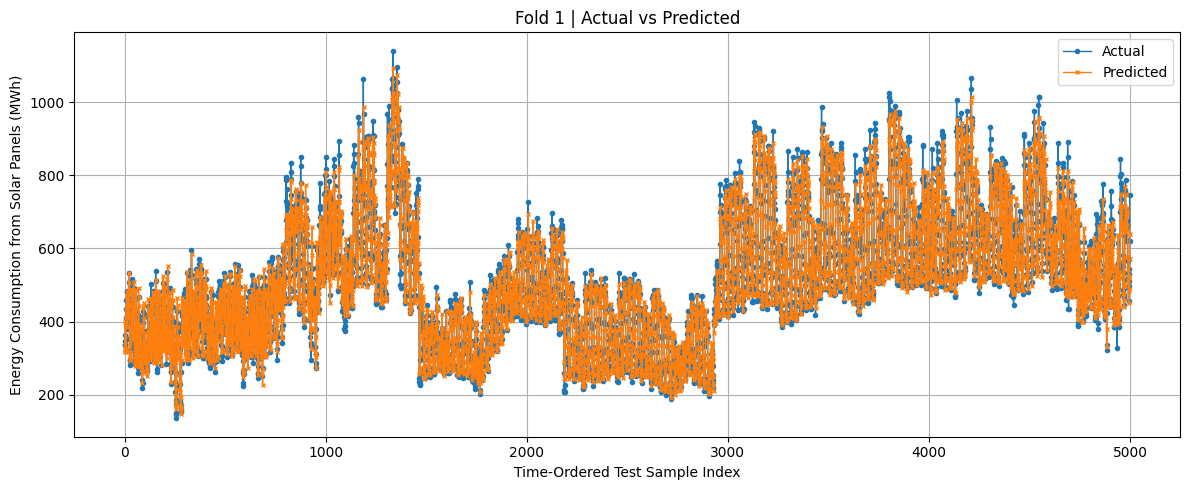


🔁 Fold 2
[0]	validation-rmse:697.45947
[50]	validation-rmse:96.03035
[90]	validation-rmse:97.74864
Train RMSE: 124.8000, Val RMSE: 97.7486, Test RMSE: 22.4975

🔁 Fold 3
[0]	validation-rmse:809.66518
[50]	validation-rmse:37.74772
[100]	validation-rmse:36.22164
[150]	validation-rmse:35.28364
[200]	validation-rmse:34.83096
[250]	validation-rmse:34.58772
[300]	validation-rmse:34.32964
[350]	validation-rmse:34.23501
[400]	validation-rmse:34.10485
[450]	validation-rmse:33.94682
[500]	validation-rmse:33.83057
[550]	validation-rmse:33.82245
[552]	validation-rmse:33.81918
Train RMSE: 91.0064, Val RMSE: 33.8192, Test RMSE: 4.9844

🔁 Fold 4
[0]	validation-rmse:997.29571
[50]	validation-rmse:17.61596
[100]	validation-rmse:15.93634
[148]	validation-rmse:15.98101
Train RMSE: 117.4428, Val RMSE: 15.9810, Test RMSE: 6.4442

🔁 Fold 5
[0]	validation-rmse:1034.49258
[50]	validation-rmse:8.21699
[100]	validation-rmse:5.99297
[125]	validation-rmse:6.03578
Train RMSE: 119.7243, Val RMSE: 6.0350, Test RMSE:

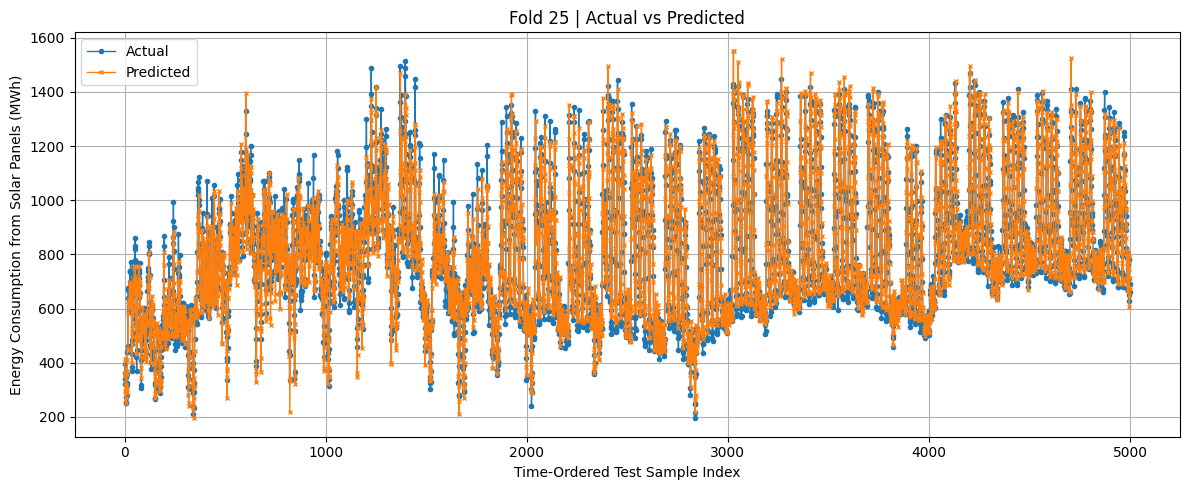


🔁 Fold 26
[0]	validation-rmse:451.83842
[50]	validation-rmse:62.94365
[100]	validation-rmse:61.02589
[150]	validation-rmse:60.89681
[173]	validation-rmse:61.00085
Train RMSE: 38.2394, Val RMSE: 61.0008, Test RMSE: 39.5005

🔁 Fold 27
[0]	validation-rmse:456.31371
[50]	validation-rmse:53.57928
[100]	validation-rmse:51.28698
[150]	validation-rmse:51.10144
[184]	validation-rmse:51.30394
Train RMSE: 39.3434, Val RMSE: 51.3039, Test RMSE: 5.1599

🔁 Fold 28
[0]	validation-rmse:295.40096
[50]	validation-rmse:28.89249
[100]	validation-rmse:27.11468
[150]	validation-rmse:26.84535
[200]	validation-rmse:26.73007
[249]	validation-rmse:26.76770
Train RMSE: 39.5693, Val RMSE: 26.7677, Test RMSE: 5.8721

🔁 Fold 29
[0]	validation-rmse:226.53144
[50]	validation-rmse:5.81567
[100]	validation-rmse:5.65705
[143]	validation-rmse:5.64921
Train RMSE: 42.4860, Val RMSE: 5.6492, Test RMSE: 9.5053

🔁 Fold 30
[0]	validation-rmse:209.69292
[50]	validation-rmse:8.37862
[100]	validation-rmse:7.99935
[150]	validatio

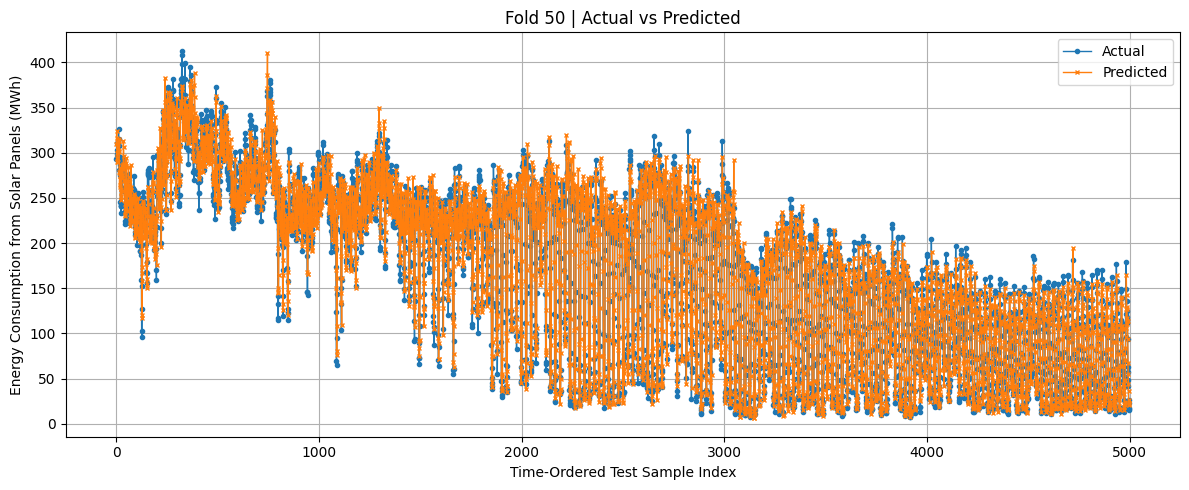


📊 Overall MAE across all folds: 24.4959


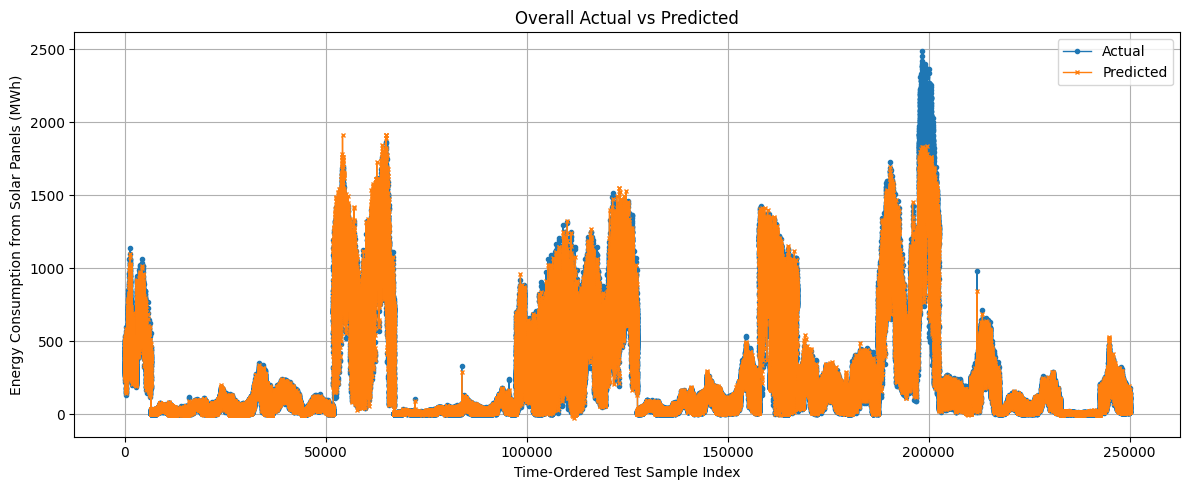

In [44]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Data Loading & Merging
def load_and_merge_data(train_path, client_path, gas_path, weather_path):
    train = pd.read_csv(train_path)
    client_data = pd.read_csv(client_path)
    gas_prices = pd.read_csv(gas_path)
    historical_weather = pd.read_csv(weather_path)
    
    # Parse dates
    train["datetime"] = pd.to_datetime(train["datetime"], errors='coerce')
    historical_weather["datetime"] = pd.to_datetime(historical_weather["datetime"], errors='coerce')
    
    # Deduplicate
    client_data = client_data.drop_duplicates(subset='data_block_id')
    gas_prices = gas_prices.drop_duplicates(subset='data_block_id')
    historical_weather = historical_weather.drop_duplicates(subset='data_block_id')
    
    # Merge auxiliary data into train
    merged_df = train.copy()
    for df in [client_data, historical_weather, gas_prices]:
        merged_df = merged_df.merge(df, on='data_block_id', how='left', suffixes=('', '_dup'))
    merged_df = merged_df.loc[:, ~merged_df.columns.str.endswith('_dup')]
    
    return merged_df, historical_weather


# 2. Feature Engineering
def engineer_features(merged_df, historical_weather):
    # Time features
    merged_df["hour"] = merged_df["datetime"].dt.hour
    merged_df["dayofweek"] = merged_df["datetime"].dt.dayofweek
    merged_df["month"] = merged_df["datetime"].dt.month
    merged_df = merged_df.sort_values(by=["prediction_unit_id", "datetime"])
    
    # Lag features
    merged_df["target_lag_24h"] = merged_df.groupby("prediction_unit_id")["target"].shift(24)
    merged_df["target_rolling_24h"] = merged_df.groupby("prediction_unit_id")["target"].rolling(24).mean().reset_index(0, drop=True)

    # Aggregate daily weather
    weather_daily = historical_weather.groupby(historical_weather["datetime"].dt.date).agg({
        "temperature": "mean",
        "shortwave_radiation": "mean",
        "cloudcover_total": "mean",
        "windspeed_10m": "mean",
        "dewpoint": "mean",
        "rain": "mean",
        "surface_pressure": "mean",
        "snowfall": "mean",
        "winddirection_10m": "mean",
        "direct_solar_radiation": "mean",
        "diffuse_radiation": "mean"
    }).reset_index().rename(columns={
        "datetime": "date",
        "temperature": "daily_avg_temp",
        "shortwave_radiation": "daily_avg_radiation",
        "cloudcover_total": "daily_avg_cloudcover",
        "windspeed_10m": "daily_avg_wind",
        "dewpoint": "daily_avg_dewpoint",
        "rain": "daily_avg_rain",
        "surface_pressure": "daily_avg_pressure",
        "snowfall": "daily_avg_snowfall",
        "winddirection_10m": "daily_avg_winddirection",
        "direct_solar_radiation": "daily_avg_direct_radiation",
        "diffuse_radiation": "daily_avg_diffuse_radiation"
    })
    
    merged_df["date"] = merged_df["datetime"].dt.date
    merged_df = merged_df.merge(weather_daily, left_on="date", right_on="date", how="left")
    
    # Filter consumption only
    consumption_df = merged_df[merged_df["is_consumption"] == True].copy()

    # Additional lag features
    lags = [1, 6, 12, 24]
    for l in lags:
        consumption_df[f"target_lag_{l}h"] = consumption_df.groupby("prediction_unit_id")["target"].shift(l)

    # Rolling means
    rolling_windows = [6, 12, 24]
    for w in rolling_windows:
        consumption_df[f"target_roll_mean_{w}h"] = (
            consumption_df.groupby("prediction_unit_id")["target"].rolling(w).mean().reset_index(0, drop=True)
        )
    
    # Lead weather features (shift backwards if forecast available)
    leads = [6]
    for lead in leads:
        consumption_df[f"temp_lead_{lead}h"] = consumption_df.groupby("prediction_unit_id")["daily_avg_temp"].shift(-lead)
        consumption_df[f"radiation_lead_{lead}h"] = consumption_df.groupby("prediction_unit_id")["daily_avg_radiation"].shift(-lead)
    
    # Select features & drop rows with NA
    base_features = [
        "hour", "dayofweek", "month",
        "lowest_price_per_mwh", "highest_price_per_mwh",
        "daily_avg_temp", "daily_avg_radiation", "daily_avg_cloudcover", "daily_avg_wind"
    ]
    lag_lead_features = [f"target_lag_{l}h" for l in lags] + \
                        [f"target_roll_mean_{w}h" for w in rolling_windows] + \
                        [f"temp_lead_{l}h" for l in leads] + \
                        [f"radiation_lead_{l}h" for l in leads]
    
    features = base_features + lag_lead_features
    consumption_df = consumption_df.dropna(subset=features + ["target"])

    X = consumption_df[features].values
    y = consumption_df["target"].values
    return X, y, features


# 3. Rolling Window Split
def rolling_window_split(X, y, train_size, val_size, test_size, max_folds=50):
    n_samples = len(X)
    for fold in range(max_folds):
        start = fold * test_size
        train_end = start + train_size
        val_end = train_end + val_size
        test_end = val_end + test_size
        if test_end > n_samples:
            break
        train_idx = np.arange(start, train_end)
        val_idx = np.arange(train_end, val_end)
        test_idx = np.arange(val_end, test_end)
        yield train_idx, val_idx, test_idx
        
def train_xgb_and_predict(X_train, y_train, X_val, y_val, X_test):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test)

    params = {
        'objective': 'reg:squarederror',
        'max_depth': 5,
        'eval_metric': 'rmse',
        'seed': 42,
        'eta': 0.1,  
    }

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50,
        verbose_eval=50
    )

    if hasattr(model, 'best_ntree_limit'):
        y_pred = model.predict(dtest, ntree_limit=model.best_ntree_limit)
    else:
        y_pred = model.predict(dtest)
    return model, y_pred



def plot_actual_vs_predicted(y_true, y_pred, title, fold=None):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label="Actual", marker='o', markersize=3, linewidth=1)
    plt.plot(y_pred, label="Predicted", marker='x', markersize=3, linewidth=1)
    plt.title(title if fold is None else f"Fold {fold} | {title}")
    plt.xlabel("Time-Ordered Test Sample Index")
    plt.ylabel("Energy Consumption from Solar Panels (MWh)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_pipeline(train_path, client_path, gas_path, weather_path,
                 train_size=150_000, val_size=1_0000, test_size=5000, max_folds=50):

    # Load and merge
    merged_df, historical_weather = load_and_merge_data(train_path, client_path, gas_path, weather_path)
    print("✅ Data loaded and merged")

    # Uncomment if you want to run EDA plots here
    # run_eda_plots(merged_df)

    # Feature engineering
    X, y, features = engineer_features(merged_df, historical_weather)
    print(f"✅ Features engineered, shape: {X.shape}")

    all_y_test, all_y_pred = [], []

    for fold, (train_idx, val_idx, test_idx) in enumerate(
            rolling_window_split(X, y, train_size, val_size, test_size, max_folds)):

        print(f"\n🔁 Fold {fold + 1}")
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        model, y_pred = train_xgb_and_predict(X_train, y_train, X_val, y_val, X_test)

        # Predict on train and val sets as well
        y_train_pred = model.predict(xgb.DMatrix(X_train))
        y_val_pred = model.predict(xgb.DMatrix(X_val))

        # Calculate RMSE for train, val, and test
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}, Test RMSE: {test_rmse:.4f}")

        all_y_test.append(y_test)
        all_y_pred.append(y_pred)

        if fold + 1 in [1, 25, 50]:
            plot_actual_vs_predicted(y_test, y_pred, "Actual vs Predicted", fold + 1)

    # Overall evaluation
    all_y_test = np.concatenate(all_y_test)
    all_y_pred = np.concatenate(all_y_pred)

    mae = mean_absolute_error(all_y_test, all_y_pred)
    print(f"\n📊 Overall MAE across all folds: {mae:.4f}")

    plot_actual_vs_predicted(all_y_test, all_y_pred, "Overall Actual vs Predicted")


# === Correct function call with file path strings ===
run_pipeline(
    train_path='/Users/manhaawan/Documents/Energy Consumption Project/train.csv',
    client_path='/Users/manhaawan/Documents/Energy Consumption Project/client.csv',
    gas_path='/Users/manhaawan/Documents/Energy Consumption Project/gas_prices.csv',
    weather_path='/Users/manhaawan/Documents/Energy Consumption Project/historical_weather.csv',
)

